# 18 · Monte Carlo simulation

Monte Carlo methods answer questions with random numbers: simulate many random cases and average.
They shine where other methods fail - integrals in many dimensions, random processes, and
probabilities of rare failures. The price: the error decreases only as $1/\sqrt N$.

Three engineering uses:
1. integration in many dimensions,
2. random walks - the microscopic picture of diffusion,
3. the probability that a structure fails.

**What you will learn**

- estimate integrals by Monte Carlo and quantify their standard error
- explain why Monte Carlo beats grids in high dimensions, and its 1/sqrt(N) cost
- connect random walks with diffusion
- estimate a structural failure probability and understand the cost of rare events

**Before you start:** notebook 01 (Monte Carlo propagation); normal distribution  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import montecarlo
from scipy import stats
from scipy.special import erf, gamma as gamma_fn

## Inside the algorithm: hit or miss
Throw random points into the square $[-1, 1]^2$; the fraction landing inside the unit circle estimates
$\pi/4$. The standard error follows from the binomial distribution:

In [2]:
rng_demo = np.random.default_rng(0)
pts = rng_demo.uniform(-1, 1, size=(100_000, 2))
hits = np.sum(pts**2, axis=1) <= 1
p_hit = hits.mean()
print(f"pi ≈ {4*p_hit:.4f} ± {4*np.sqrt(p_hit*(1 - p_hit)/hits.size):.4f}")

pi ≈ 3.1471 ± 0.0052


## Why Monte Carlo wins in high dimensions
Estimate the volume of the unit ball in $d$ dimensions (exact: $\pi^{d/2}/\Gamma(d/2+1)$) with the same
budget of about one million function evaluations: a grid (midpoint rule, $m$ points per axis, $m^d$ in
total) versus random points.

In [3]:
budget = 1_000_000
inside = lambda p: (np.sum(p**2, axis=1) <= 1.0).astype(float)
print(f"{'d':>3}{'points/axis':>12}{'grid error':>12}{'MC error':>11}{'MC std. error':>15}")
for d in (2, 3, 5, 8, 10):
    exact = np.pi**(d/2) / gamma_fn(d/2 + 1)
    m = int(round(budget ** (1/d)))
    axis = -1 + (np.arange(m) + 0.5) * 2/m                  # midpoints of m cells on [-1, 1]
    grid = np.stack(np.meshgrid(*([axis] * d), indexing="ij"), axis=-1).reshape(-1, d)
    grid_est = inside(grid).mean() * 2**d
    mc_est, mc_se = montecarlo.integrate(inside, [(-1, 1)] * d, m**d, seed=d)
    print(f"{d:>3}{m:>12}{abs(grid_est/exact - 1):>11.2%}{abs(mc_est/exact - 1):>11.2%}{mc_se/exact:>14.2%}")

  d points/axis  grid error   MC error  MC std. error
  2        1000      0.01%      0.02%         0.05%


  3         100      0.07%      0.07%         0.10%


  5          16      0.91%      0.06%         0.22%


  8           6      2.90%      0.22%         0.61%


 10           4     60.79%      0.89%         1.95%


In two and three dimensions the grid is at least as accurate as Monte Carlo (compare with the Monte
Carlo *standard error*, its typical error; a single run can be luckier). By five dimensions the grid falls
behind, and in ten dimensions - only 4 points per axis - its error is huge, while Monte Carlo's error
barely depends on the dimension. This is why Monte Carlo is used for high-dimensional
problems - uncertainty propagation with many inputs (notebook 01), statistical physics, finance.

## The $1/\sqrt N$ law

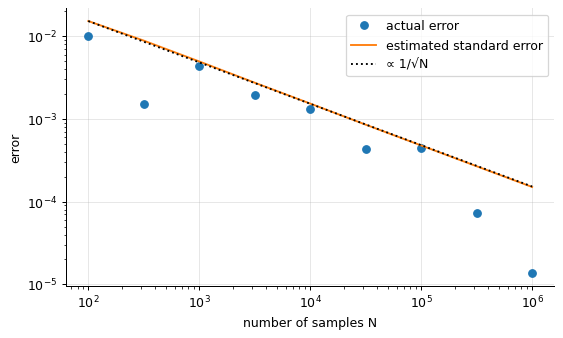

In [4]:
f5 = lambda p: np.exp(-np.sum(p**2, axis=1))            # integral over [0, 1]^5 is known exactly
exact5 = (np.sqrt(np.pi)/2 * erf(1))**5
Ns = np.logspace(2, 6, 9).astype(int)
errs = [abs(montecarlo.integrate(f5, [(0, 1)]*5, N, seed=1)[0] - exact5) for N in Ns]
ses = [montecarlo.integrate(f5, [(0, 1)]*5, N, seed=1)[1] for N in Ns]
plt.loglog(Ns, errs, "o", label="actual error")
plt.loglog(Ns, ses, "-", label="estimated standard error")
plt.loglog(Ns, ses[0]*np.sqrt(Ns[0]/Ns), "k:", label="∝ 1/√N")
plt.xlabel("number of samples N"); plt.ylabel("error"); plt.legend(); plt.show()

One more correct digit costs **100 times** more samples. The standard error, estimated from the samples
themselves, tells you how far to trust the result.

## Random walks and diffusion
A molecule in a liquid is knocked about randomly. Model it as a walker taking unit steps in random
directions. After $n$ steps its mean squared displacement is $\langle r^2\rangle = n$ - it grows linearly
in time, the signature of diffusion ($\langle r^2\rangle = 2dDt$ in $d$ dimensions).

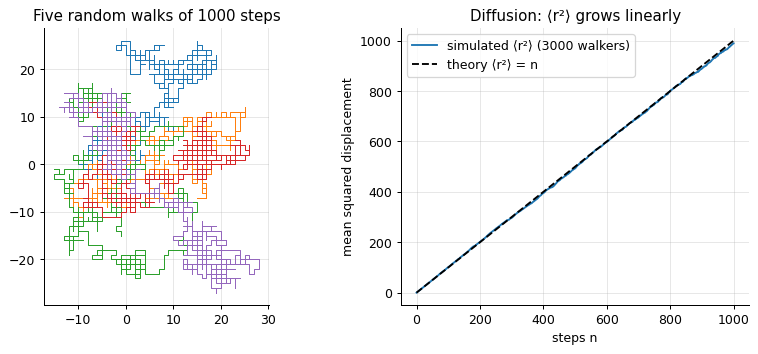

In [5]:
paths = montecarlo.random_walk(1000, 5, dim=2, seed=1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for w in range(5):
    a1.plot(paths[:, w, 0], paths[:, w, 1], lw=0.8)
a1.set(aspect="equal", title="Five random walks of 1000 steps")
walk = montecarlo.random_walk(1000, 3000, dim=2, seed=2)
msd = np.mean(np.sum(walk**2, axis=2), axis=1)
a2.plot(msd, label="simulated ⟨r²⟩ (3000 walkers)"); a2.plot([0, 1000], [0, 1000], "k--", label="theory ⟨r²⟩ = n")
a2.set(xlabel="steps n", ylabel="mean squared displacement", title="Diffusion: ⟨r²⟩ grows linearly"); a2.legend()
plt.show()

The positions of many 1D walkers after $n$ steps approach a Gaussian of variance $n$ (central limit
theorem) - exactly the solution of the diffusion equation from a point source, whose error-function
form appeared in notebook 12. Random walks and the diffusion PDE are two views of one phenomenon.

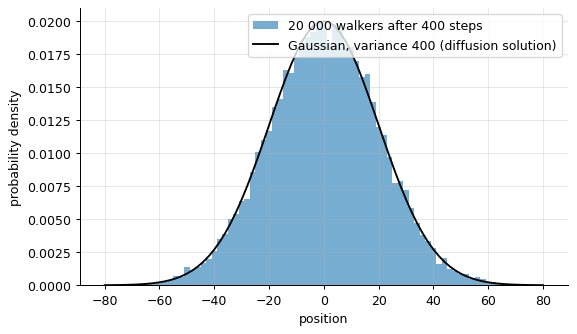

In [6]:
ends = montecarlo.random_walk(400, 20000, seed=3)[-1, :, 0]
xs = np.arange(-80, 81, 2)
plt.hist(ends, bins=np.arange(-81, 82, 2), density=True, alpha=0.6, label="20 000 walkers after 400 steps")
plt.plot(xs, stats.norm.pdf(xs, 0, np.sqrt(400)), "k", label="Gaussian, variance 400 (diffusion solution)")
plt.xlabel("position"); plt.ylabel("probability density"); plt.legend(); plt.show()

## Probability of failure
A steel member has a strength $S$ and carries a load effect $L$, both uncertain: $S \sim N(400, 25)$ MPa
and $L \sim N(300, 30)$ MPa. It fails when $L > S$. For normal variables the answer is exact,
$P_f = \Phi\!\left(-\frac{\mu_S - \mu_L}{\sqrt{\sigma_S^2 + \sigma_L^2}}\right)$; Monte Carlo just counts failures:

In [7]:
pf_exact = stats.norm.cdf(-(400 - 300) / np.hypot(25, 30))
rng = np.random.default_rng(18)
for N in (10_000, 1_000_000):
    fails = rng.normal(300, 30, N) > rng.normal(400, 25, N)
    p = fails.mean()
    print(f"N = {N:>9,}: P_f = {p:.5f} ± {np.sqrt(p*(1-p)/N):.5f}   (exact {pf_exact:.5f})")
print(f"samples needed for ±10 % relative error: about {int((1 - pf_exact)/(pf_exact*0.1**2)):,}")

N =    10,000: P_f = 0.00450 ± 0.00067   (exact 0.00522)
N = 1,000,000: P_f = 0.00526 ± 0.00007   (exact 0.00522)
samples needed for ±10 % relative error: about 19,047


Rare events are expensive: the number of samples needed grows like $1/P_f$. Monte Carlo's strength is that
**nothing** in the method assumed normal distributions. Suppose the load is better described by a
skewed lognormal distribution with the same mean and standard deviation - no simple formula exists,
but the simulation is unchanged:

In [8]:
sig_ln = np.sqrt(np.log(1 + (30/300)**2)); mu_ln = np.log(300) - sig_ln**2/2
N = 2_000_000
load = rng.lognormal(mu_ln, sig_ln, N)
p_ln = np.mean(load > rng.normal(400, 25, N))
print(f"lognormal load: P_f = {p_ln:.5f} ± {np.sqrt(p_ln*(1 - p_ln)/N):.5f}  vs normal load {pf_exact:.5f}")

lognormal load: P_f = 0.00733 ± 0.00006  vs normal load 0.00522


The heavier upper tail of the lognormal load raises the failure probability noticeably: in reliability,
the **tails** of the distributions decide the answer.

## Exercises
1. Estimate $\pi$ with Buffon's needle: drop needles of length $\ell$ on lines spaced $d \ge \ell$ apart;
   $P(\text{cross}) = 2\ell/(\pi d)$. How many throws for three correct digits?
2. **Importance sampling.** Draw loads from $N(360, 30)$ instead of $N(300, 30)$ (more failures) and
   correct each sample with the weight $\phi_{300}(L)/\phi_{360}(L)$. How much smaller is the standard
   error for the same N?
3. Simulate 3D walks and confirm $\langle r^2\rangle = n$. Use the result to relate the step length and time
   step of a walker to a diffusion coefficient $D$.
4. **Implement it yourself:** write a Monte Carlo estimate of the probability that the sum of 12 uniform(0, 1) numbers exceeds 8, with its standard error. Compare with the normal approximation (mean 6, variance 1) and explain the difference.